# Continual leg-damage adaptation — analysis

Figures for the paper from `results/continual_events.csv` (written by `run_experiment.py`). Reusable logic lives in `methods/continual_analysis.py`; this notebook is a thin driver so the plots can be tweaked and viewed inline.

Regenerate the results first if needed:
```bash
python experiment-damage-adapt/run_experiment.py --seeds 5 --duration 120
```

In [1]:
import os, sys
%matplotlib inline

# locate the repo root (the directory containing 'methods/'), robust to CWD
root = os.path.abspath('')
while root != os.path.dirname(root) and not os.path.isdir(os.path.join(root, 'methods')):
    root = os.path.dirname(root)
if root not in sys.path:
    sys.path.insert(0, root)

from methods import continual_analysis as ca

EXP         = 'experiment-damage-adapt'
TITLE       = 'Continual leg-damage adaptation'
EVENT_WORD  = 'leg-damage'
EXT         = 'png'          # switch to 'pdf' for the camera-ready
RESULTS_DIR = os.path.join(root, EXP, 'results')
FIG_DIR     = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

rows = ca.load_events(RESULTS_DIR)
print(f'loaded {len(rows)} events across arms:', ca.methods_present(rows))

loaded 141 events across arms: ['noadapt', 'grid', 'bo', 'safegp', 'oracle']


## Per-method summary
Fall rate, stability (surviving RMS body tilt), and distance travelled — mean ± SEM across seeds (real events only; false alarms excluded).

In [2]:
ca.summary_dataframe(rows)

,seeds,events,fall_rate_%,fall_rate_sem,tilt_deg,tilt_sem,dist_m,dist_sem
method,,,,,,,,
No adaptation,4,15,0.00,0.00,5.52,0.20,22.06,2.84
Grid search,4,27,73.51,8.17,6.47,0.63,27.65,1.32
Bayesian opt.,4,24,45.71,2.54,6.02,1.44,25.76,1.20
Safe GP (ours),4,24,52.62,13.02,5.72,0.99,26.14,1.50
Oracle,4,17,5.00,5.00,3.21,0.18,27.70,1.69


## Headline: fall rate / stability / distance per method
The three metrics side by side. `noadapt` is the lower anchor (hatched gray), `oracle` the upper anchor; `safegp` is the proposed method.

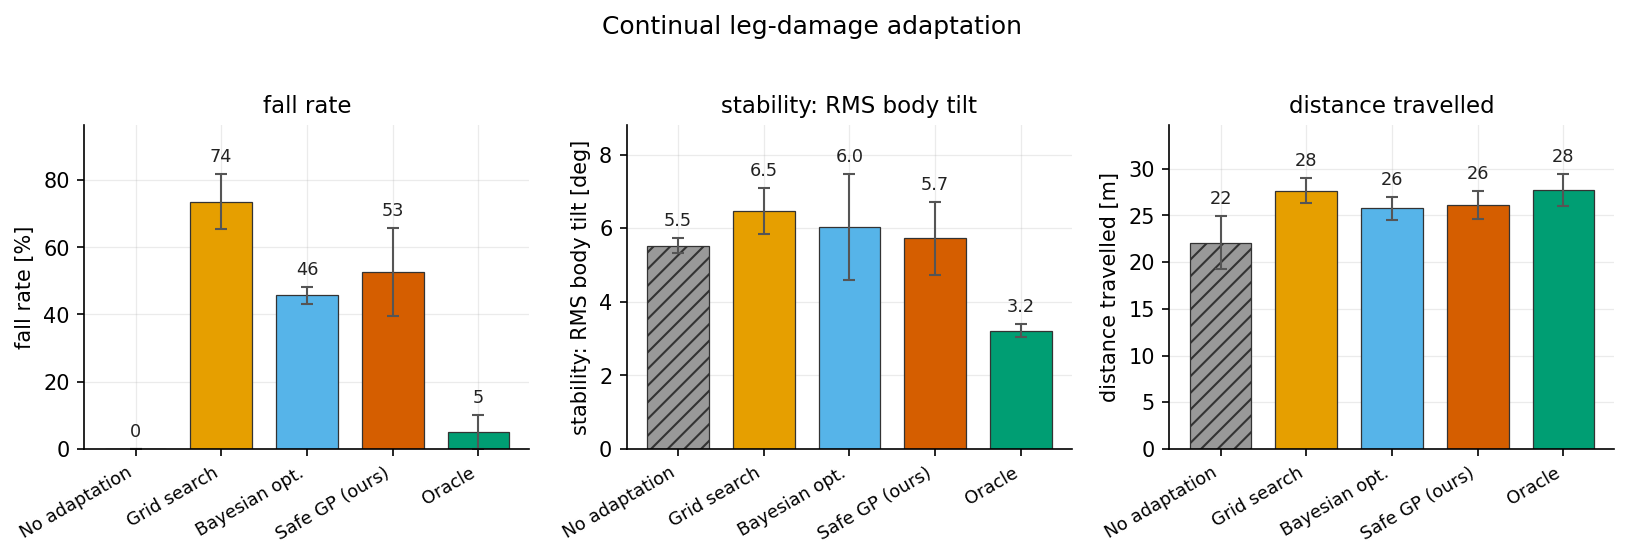

In [3]:
fig = ca.fig_comparison(rows, TITLE, EVENT_WORD,
                        out_path=os.path.join(FIG_DIR, f'method_comparison.{EXT}'))

## Learning curve
Fall rate vs event number within the trial. The search-based arms (`safegp`, `bo`) should thin out falls as their memory fills; `grid` does not learn and the anchors stay flat.

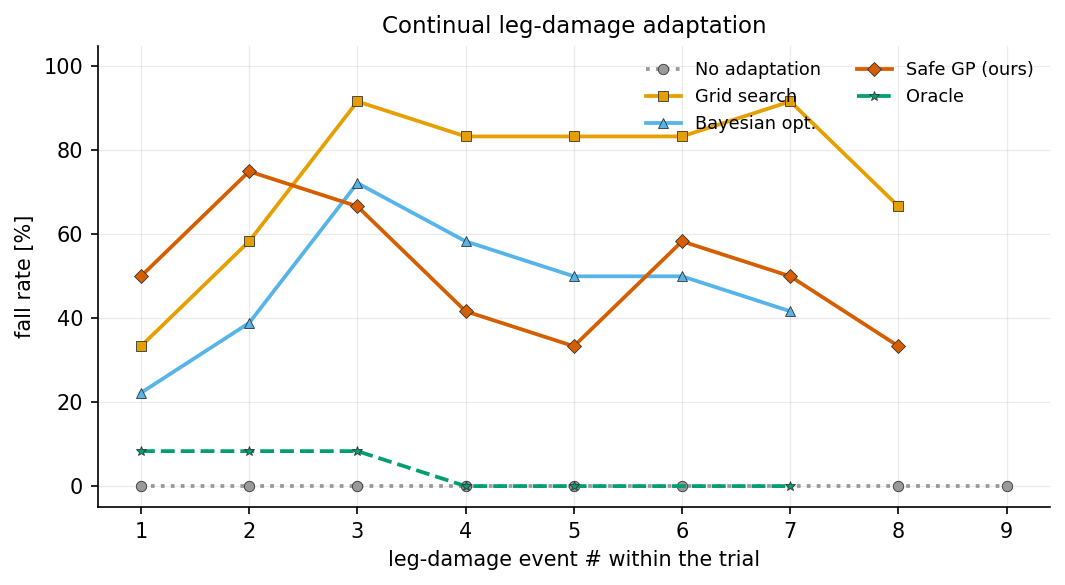

In [4]:
fig = ca.fig_learning(rows, TITLE, EVENT_WORD,
                      out_path=os.path.join(FIG_DIR, f'learning_curve.{EXT}'))

## Example time series (seed 0)
Forward-speed trace per method; orange = event engaged, green = the method responding. Needs the per-seed `results/logs/*.npz` traces.

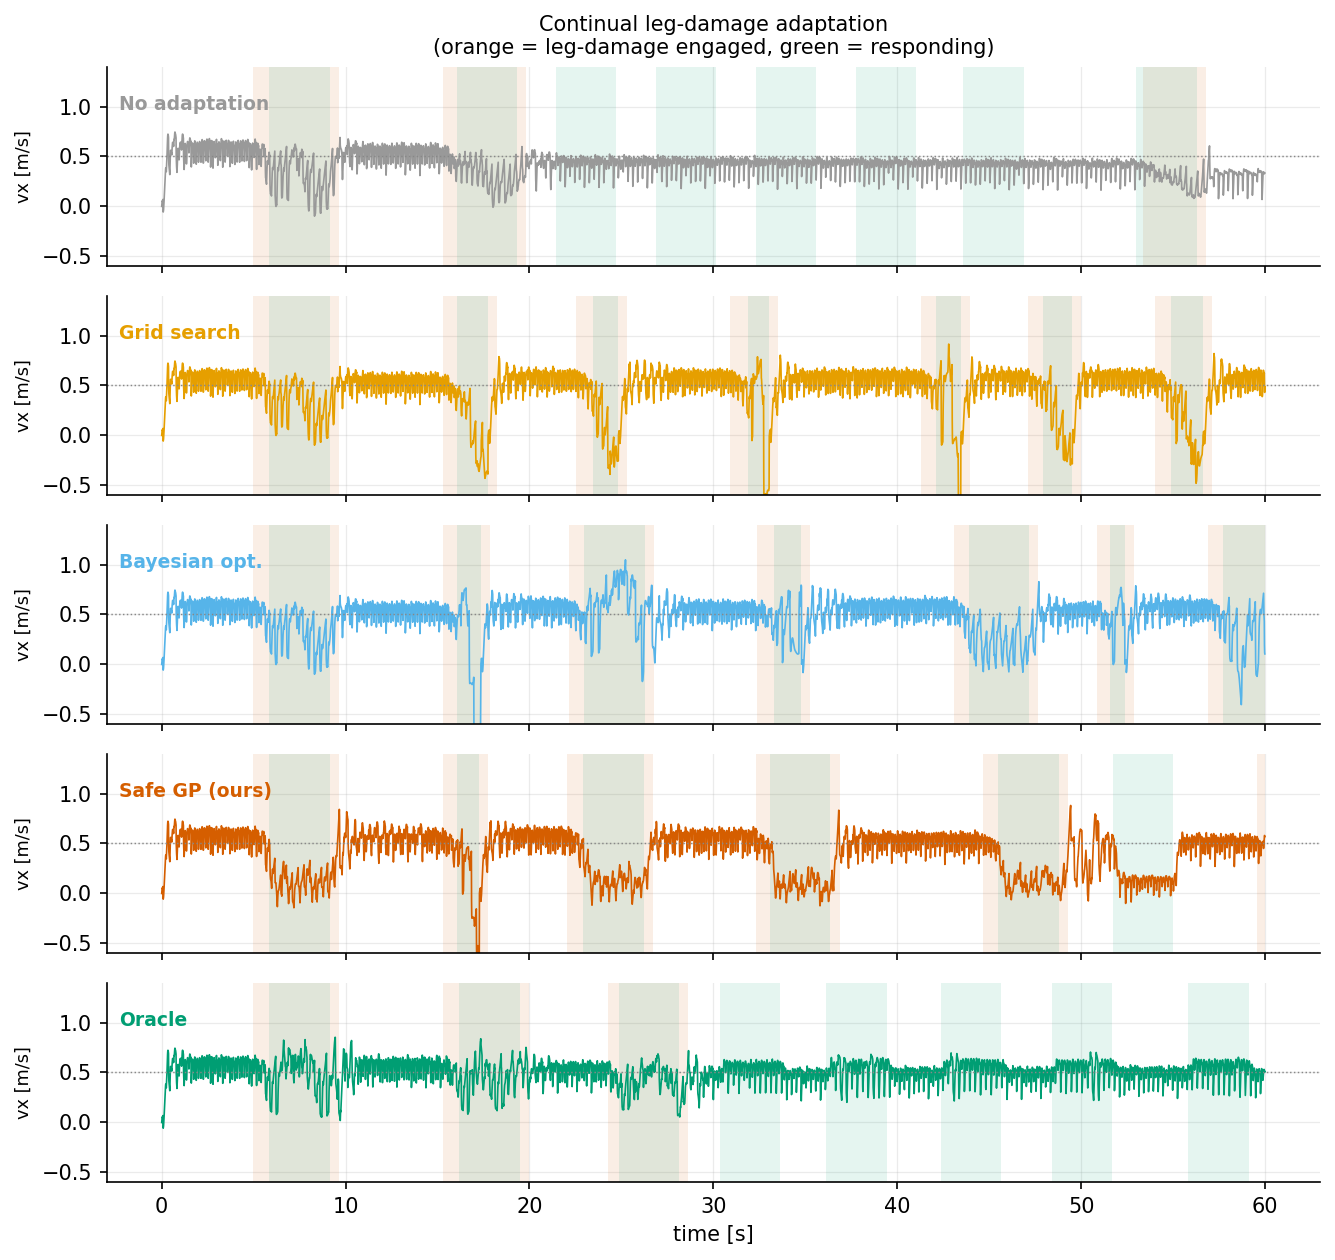

In [5]:
fig = ca.fig_timeseries(RESULTS_DIR, TITLE, EVENT_WORD, seed=0,
                        out_path=os.path.join(FIG_DIR, f'timeseries_seed0.{EXT}'))
if fig is None:
    print('no per-seed logs found in', os.path.join(RESULTS_DIR, 'logs'))